Прогнозирование временных рядов

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns

In [170]:
df_test = pd.read_excel('Test.xlsm')
df_train = pd.read_excel('Train.xlsm')

Загружаем данные и преобразуем в датафрейм 

In [171]:
len(df_train.columns[0].split(','))

17

In [172]:
def data_parsing_and_cover(data, title):
    all_data = []
    
    # формат даты-времени 
    time_format = '%H:%M:%S' # ЧАСЫ-МИНУТЫ-СЕКУНДЫ
    date_format = '%Y-%m-%d' # ГОД-МЕСЯЦ-ДЕНЬ
    datetime_format = '%Y-%m-%d %H:%M:%S'

    #заголовки колонок
    headers = data.iloc[0:0]

    for i in range(0, len(data)):
        row_data = data.iloc[i, 0].split(',')
        all_data.append(row_data)

    data_df = pd.DataFrame(all_data)
    last_ind = len(df_train.columns[0].split(','))

    #Изменяем названия колонок
    data_df = data_df.set_index(pd.to_datetime(data_df[3].values, format=datetime_format)).drop(labels=[3], axis=1)
    if title.lower() == 'train':
        data_df.rename(columns={16: 'Target', 0: "№ наблюдения"}, inplace=True)
    else:
        data_df.rename(columns={0: "№ наблюдения"}, inplace=True)

    for ind, column in enumerate(data_df.columns[1:last_ind]):
        data_df.rename(columns={ind+1: f'Feature №{ind+1}'}, inplace=True)
    
    return data_df


data_test = data_parsing_and_cover(df_test, title='test')
data_train = data_parsing_and_cover(df_train, title='train')


In [173]:
# узнаем текущую частоту индексов в трейне и тесте
print(data_train.index.inferred_freq) # -> None
print(data_test.index.inferred_freq) # -> None

None
None


 Неравномерные интервалы между датами

In [174]:
#проверка на None
print(data_train.isna().sum())
print('================')
print(f'Дубли - {data_train.duplicated().sum()}')

№ наблюдения    0
Feature №1      0
Feature №2      0
Feature №4      0
Feature №5      0
Feature №6      0
Feature №7      0
Feature №8      0
Feature №9      0
Feature №10     0
Feature №11     0
Feature №12     0
Feature №13     0
Feature №14     0
Feature №15     0
Target          0
dtype: int64
Дубли - 0


Видим, что дублей нету, но в датасете есть пустые строки в место None. Необходимо их заменить на None, а после определиться будем ли мы их заполнять или удалим

In [175]:
data_train = data_train.where(data_train != '', np.nan)

Теперь посчитаем Nan

In [176]:
print(data_train.isna().sum())
print(f'Размерность датасета - {data_train.shape}')

#пропусков не более 10%. Удаляем!

data_train = data_train.dropna()


№ наблюдения     0
Feature №1       0
Feature №2       0
Feature №4       0
Feature №5       0
Feature №6       0
Feature №7      18
Feature №8      18
Feature №9      18
Feature №10      3
Feature №11      4
Feature №12      3
Feature №13      4
Feature №14      4
Feature №15     32
Target           2
dtype: int64
Размерность датасета - (615, 16)


In [177]:
#Посмотрим основные стат покзаатели датасета
data_train.describe()


,№ наблюдения,Feature №1,Feature №2,Feature №4,Feature №5,Feature №6,Feature №7,Feature №8,Feature №9,Feature №10,Feature №11,Feature №12,Feature №13,Feature №14,Feature №15,Target
count,563,563,563,563,563,563,563,563,563,563,563,563,563,563,563,563
unique,563,563,5,514,536,522,560,560,560,169,563,456,113,398,563,154
top,8,3.916371641148814,4,1684.7122739999998,59.93333333333329,2.349485342019539,0.06752157853560957,7.351261005663045,4.35637385273047,0.00132,1.5161578408690806,52.585049999999995,0.34316064,0.22123636363636368,1.3438693081359883,0.77
freq,1,1,129,6,3,3,3,3,3,12,1,4,15,9,1,15


Видим, что в датасете некорректный тип данных, а также категориальную фичу №2 с 5 уникальными значениями . Необходимо провести преобразование типов

In [178]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 563 entries, 2023-06-16 15:30:00 to 2023-09-02 17:30:00
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   № наблюдения  563 non-null    object
 1   Feature №1    563 non-null    object
 2   Feature №2    563 non-null    object
 3   Feature №4    563 non-null    object
 4   Feature №5    563 non-null    object
 5   Feature №6    563 non-null    object
 6   Feature №7    563 non-null    object
 7   Feature №8    563 non-null    object
 8   Feature №9    563 non-null    object
 9   Feature №10   563 non-null    object
 10  Feature №11   563 non-null    object
 11  Feature №12   563 non-null    object
 12  Feature №13   563 non-null    object
 13  Feature №14   563 non-null    object
 14  Feature №15   563 non-null    object
 15  Target        563 non-null    object
dtypes: object(16)
memory usage: 74.8+ KB


In [179]:

data_train_num = data_train.drop(labels=['Feature №2'], axis=1)


#Преобразуем количиственные признаки в вещественные числа
data_train_num[data_train_num.columns] = data_train_num[data_train_num.columns].astype('float64')

#Категорильную фичу в categorical
data_train_cat =  data_train['Feature №2'].astype('category')


In [180]:
#Cтроим повторно описание основных стат показателей датасета
data_train_num.describe()

,№ наблюдения,Feature №1,Feature №4,Feature №5,Feature №6,Feature №7,Feature №8,Feature №9,Feature №10,Feature №11,Feature №12,Feature №13,Feature №14,Feature №15,Target
count,563.000000,563.000000,563.000000,563.000000,563.000000,563.000000,563.000000,563.000000,563.000000,563.000000,563.000000,563.000000,563.000000,563.000000,563.000000
mean,311.952043,4.751765,10071.473628,62.470240,2.594087,0.090475,7.875723,4.923084,0.002775,1.524396,53.846824,0.362160,0.189003,1.360212,0.777392
std,178.864328,18.713751,5751.625967,8.518194,2.380970,0.027326,0.934485,0.564118,0.000767,0.080979,9.195138,0.069351,0.105887,0.088330,0.157389
min,8.000000,0.565261,1313.611698,9.317035,0.744419,0.023705,3.581151,3.250178,0.001320,1.269232,19.257700,0.026602,0.001844,1.028639,0.378000
25%,157.500000,3.591426,3134.824023,60.451442,2.346028,0.073269,7.586573,4.612559,0.002270,1.475902,47.994800,0.329860,0.115873,1.324410,0.679000
50%,307.000000,4.130857,9397.295586,62.389633,2.585597,0.080949,8.014372,4.870144,0.002666,1.535061,53.161500,0.367102,0.174777,1.378877,0.784000
75%,473.500000,4.386457,14739.475079,64.308090,2.676102,0.114347,8.342976,5.220168,0.003142,1.570761,59.267600,0.404344,0.226767,1.416498,0.857500
max,614.000000,447.689555,19130.656398,214.510626,58.526671,0.163735,9.932541,7.076745,0.007788,2.050514,87.108000,0.673020,0.776171,1.590728,2.075500


Видм, что фичи №4, №5, №6, №12 имеют в разы больший масштаб, чем остальные. Поэтому будем  SCALE данные

In [181]:
#Проведем ресемпл временных интервалов

frequencies = ['30T', '1H', '3H', '6H', '12H', '1D']


def choose_freq_time_series(data, freq):  
    freq_results = []
    data_to_cover = data
    for freq in frequencies:
        data_new = data_to_cover.resample(freq).mean()
        data_new = data_new.interpolate(method='linear')
        freq_results.append(data_new)
    return freq_results

sample_results = choose_freq_time_series(data=data_train_num, freq=frequencies)


title = []
for sample in sample_results:
    print(sample.shape[0], sample.index.inferred_freq)
    title.append(sample.index.inferred_freq)



3749 30min
1875 h
625 3h
313 6h
157 12h
79 D


/var/folders/py/y2s4dn6x3_x0nwh8f_w5r68w0000gn/T/ipykernel_93406/2768992732.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  data_new = data_to_cover.resample(freq).mean()
/var/folders/py/y2s4dn6x3_x0nwh8f_w5r68w0000gn/T/ipykernel_93406/2768992732.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data_new = data_to_cover.resample(freq).mean()
/var/folders/py/y2s4dn6x3_x0nwh8f_w5r68w0000gn/T/ipykernel_93406/2768992732.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data_new = data_to_cover.resample(freq).mean()
/var/folders/py/y2s4dn6x3_x0nwh8f_w5r68w0000gn/T/ipykernel_93406/2768992732.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data_new = data_to_cover.resample(freq).mean()
/var/folders/py/y2s4dn6x3_x0nwh8f_w5r68w0000gn/T/ipykernel_93406/2768992732.py

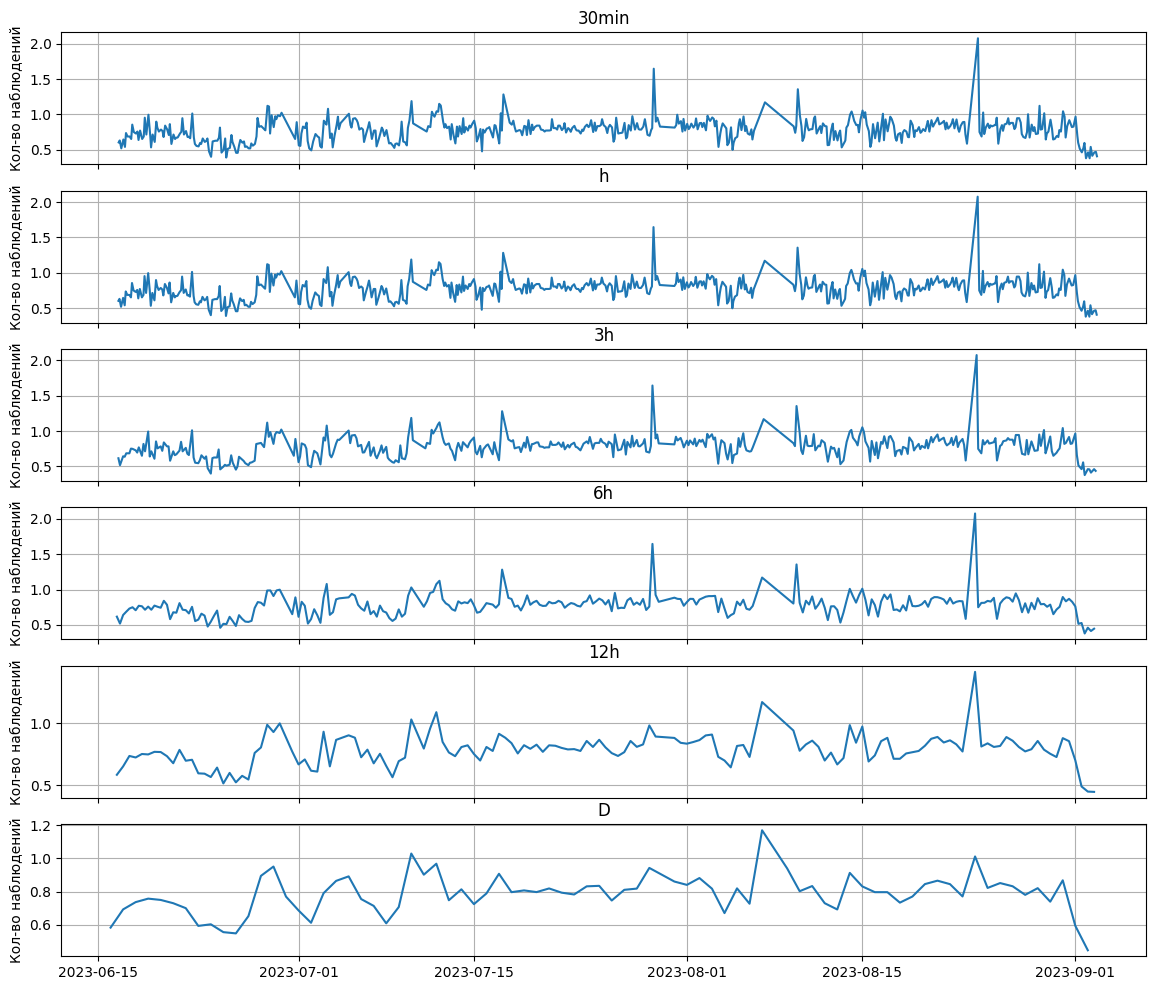

In [182]:
fig, axes = plt.subplots(len(sample_results), 1, figsize=(14, 12), sharex=True)

# в цикле отрисовываем графики
for ax, series, one_title in zip(axes, sample_results, title):
    ax.plot(series.index, series['Target'])
    ax.set_title(one_title)
    ax.set_ylabel('Кол-во наблюдений')
    ax.grid(True)
plt.show()

Видим что у нас в днях есть незначительные пропуски и на промежутке 12 часов. 

### Выбираем семпл временного периода в промежутках 12 часов!

In [183]:
result_num = sample_results[-1]
result_cat = data_train_cat.resample('1D').apply(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

При агрегации и ресемплинге Series сохранилось соотношение кат фичи

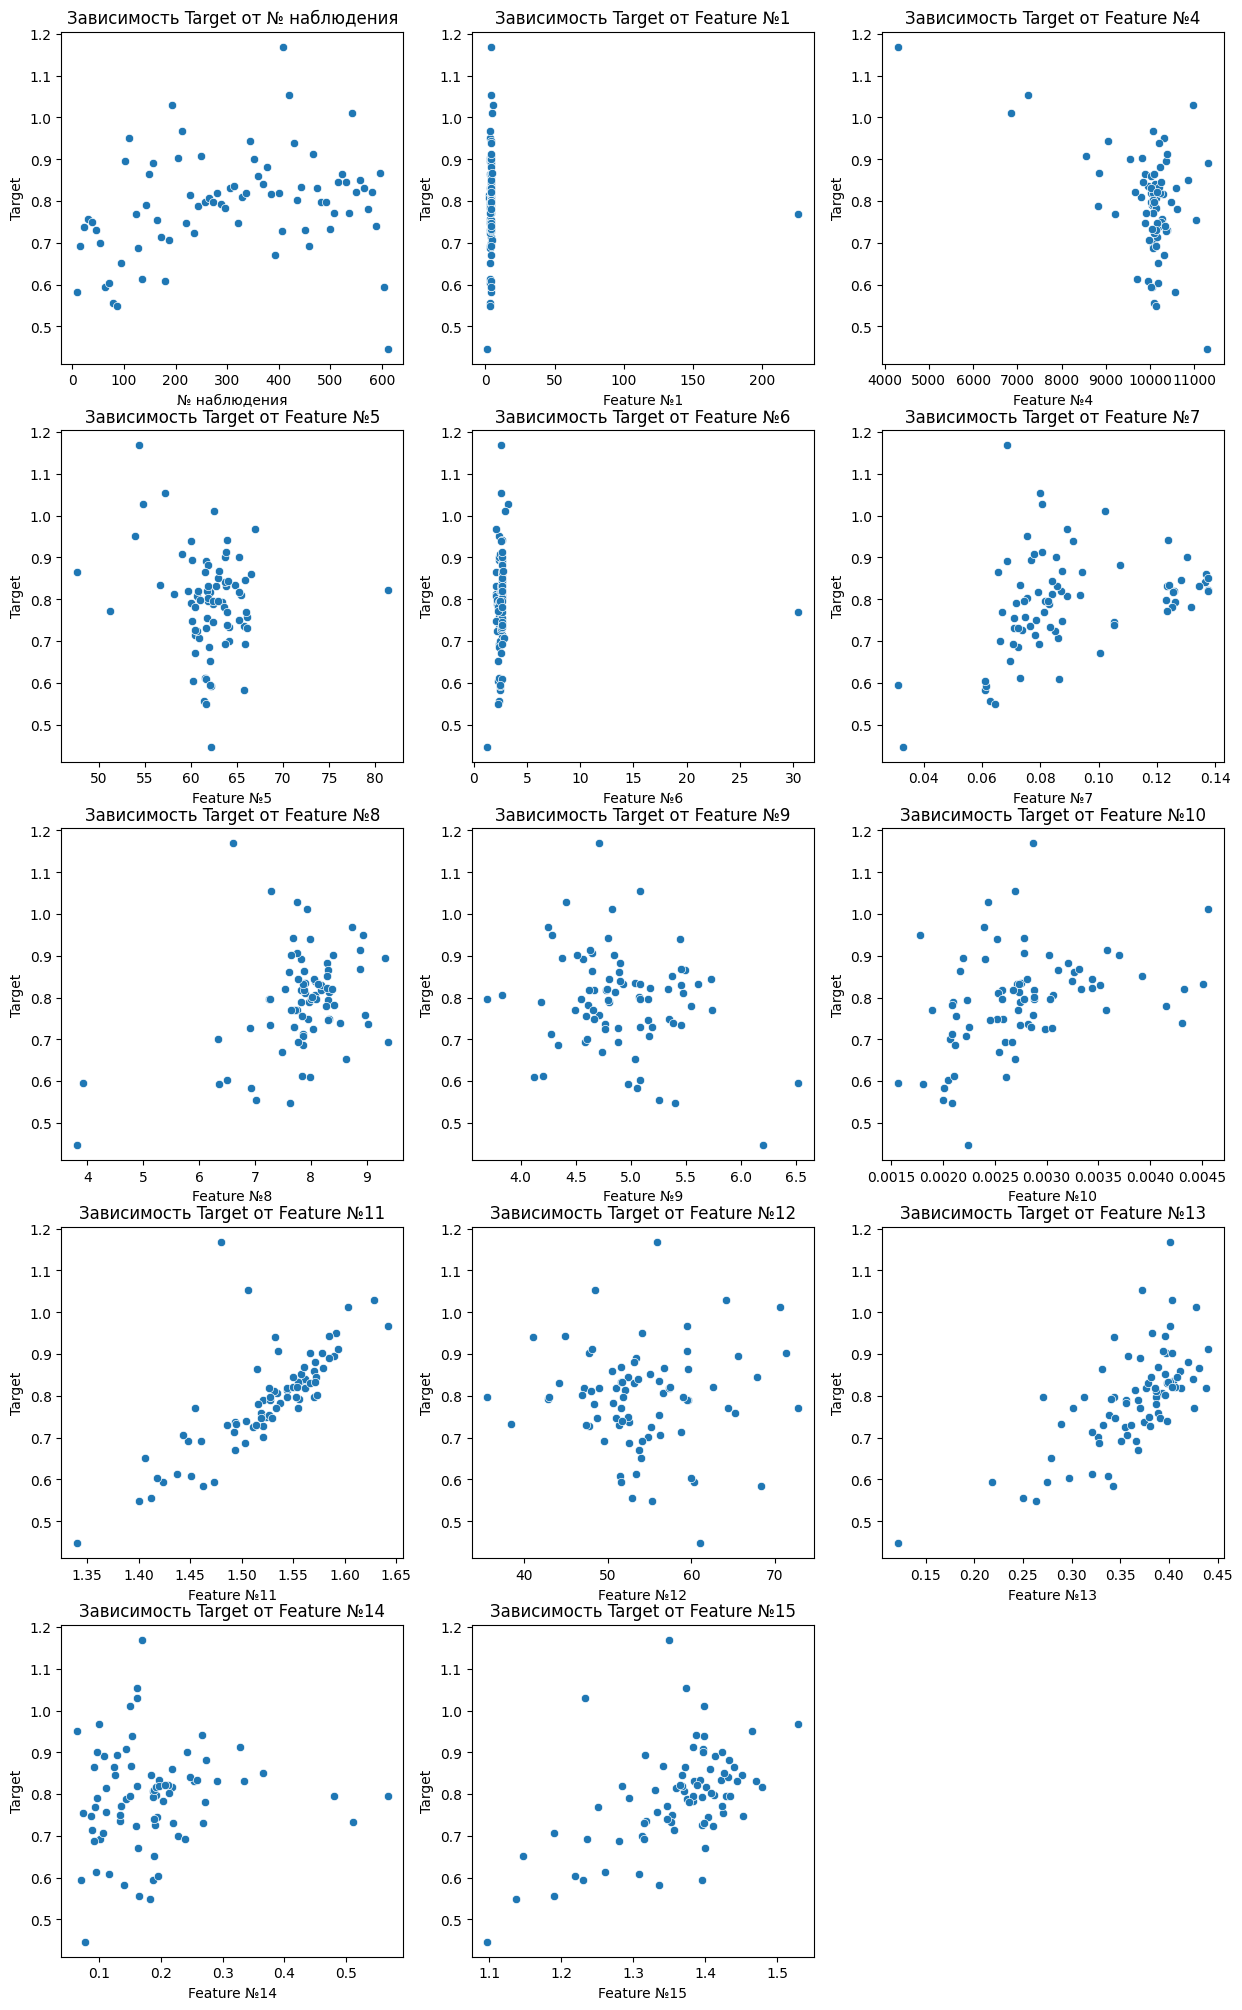

In [184]:
def plots_correlation_numeric_features_with_target(data, num_col):
    num_col = num_col.to_list()
    num_col.remove('Target')
    target = 'Target'
    n_cols = 3
    n_rows = (len(num_col) + n_cols) // 3
    plt.figure(figsize=(15,25))
    for i, feature in enumerate(num_col):
        plt.subplot(n_rows, n_cols, i+1)
        sns.scatterplot(data=data, x=feature, y=target)
        plt.xlabel(feature)
        plt.ylabel("Target")
        plt.title(f"Зависимость {target} от {feature}")   

plots_correlation_numeric_features_with_target(data=result_num, num_col=result_num.columns)

<Axes: >

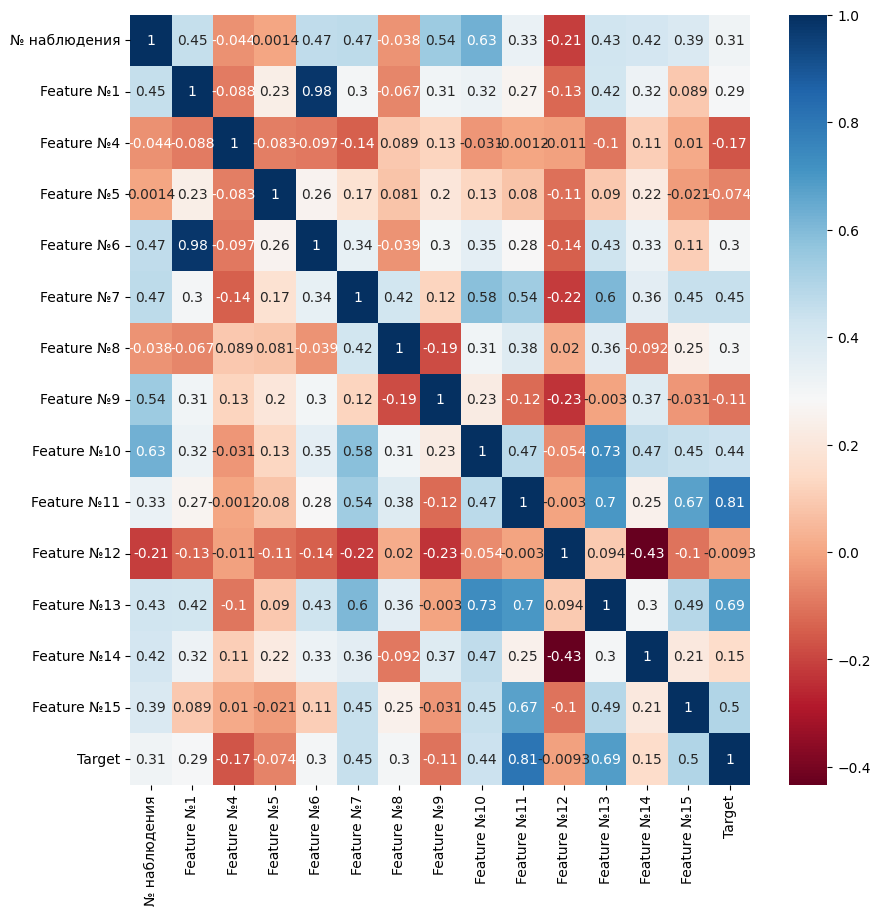

In [185]:
plt.figure(figsize=(10,10))
sns.heatmap(data=result_num.corr(method='spearman'), annot=True, cmap='RdBu')

Наблюдаем сильные линейные связи у признаков -  мультиколлениарность!

In [186]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


def search_multicollinear(df, num_col):
    """Функция вычисляющая Фактор инфляции дисперсии (VIF) и сигнализирует о наличии и силы мультиколлинеарности у независимых фич"""
    df = df[num_col].drop(labels=['Target','№ наблюдения'], axis=1) # выбираем кол-ые признаки, удаляем таргет
    df = df.fillna(df.mean()) # обрабатываем пропуски в данных
    X_with_const = add_constant(df) #добавляем константу в датафрейм т.к. VIF не работает с пропусками
    X_features = X_with_const.columns  #определяем названия колонок фичей
    vif_df = pd.DataFrame() # формируем пустой датафрейм для организации расчетных  итоговых цифр 
    vif_df['feature'] = X_features # заполняем датафрейм названиями независимых фич
    vif_df['VIF'] = [variance_inflation_factor(X_with_const.values,i)  for i in range(X_with_const.shape[1])] #посредством list comprehension записываем итоговые VIF коэффициенты в датафрейм 
    #валидация итоговых результатов
    print('=================================================================')
    if vif_df.iloc[1:,:].max()[1] > 10:
        print("Присутствует сильная мультиколлинеарность")
    elif vif_df.iloc[1:,:].max()[1] < 10 and vif_df.iloc[1:,:].max()[1] > 5:
        print("Присутствует умеренная мультиколлинеарность")
    else:
        print("Мультиколлинеарность незначительная или отсутствует вовсе ")
    print('=================================================================')

    return vif_df # возвращаем VIF коэффициенты по каждой фиче


In [187]:
vif_feature = search_multicollinear(df=result_num, num_col=result_num.columns)
vif_feature

Присутствует сильная мультиколлинеарность


/var/folders/py/y2s4dn6x3_x0nwh8f_w5r68w0000gn/T/ipykernel_93406/1364050096.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if vif_df.iloc[1:,:].max()[1] > 10:


,feature,VIF
0,const,2085.426752
1,Feature №1,579.454911
2,Feature №4,1.248781
3,Feature №5,1.210507
4,Feature №6,575.022817
5,Feature №7,2.063106
6,Feature №8,2.331028
7,Feature №9,1.884125
8,Feature №10,2.845270
9,Feature №11,4.216683


In [188]:
#Удаляем признаки с высокой мультиколлениарностью
feature_to_drop = []

for i, feature in enumerate(vif_feature['feature'].to_list()[1:]):
    if vif_feature['VIF'][i+1] > 10:
        feature_to_drop.append(feature)
feature_to_drop.append('№ наблюдения')
result_num.drop(labels=feature_to_drop, axis=1, inplace=True)

In [189]:
result_num.head(2)

,Feature №4,Feature №5,Feature №7,Feature №8,Feature №9,Feature №10,Feature №11,Feature №12,Feature №13,Feature №14,Feature №15,Target
2023-06-16,10554.401109,65.752240,0.061058,6.938155,5.056275,0.002006,1.462682,68.355583,0.342274,0.139748,1.336288,0.583333
2023-06-17,10065.220141,65.913061,0.079618,9.380181,4.582039,0.002595,1.447508,49.542675,0.366437,0.101700,1.235773,0.693000


## ассмотрим как расперделен таргет в кат фиче.

Text(0.5, 1.0, 'Распредление таргета в зависомости от значений категориально признака Фича №2')

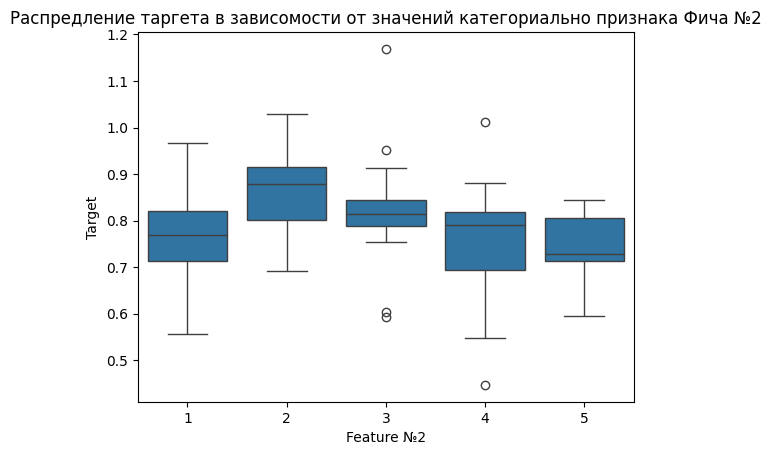

In [190]:
sns.boxplot(y=result_num['Target'], x=result_cat)
plt.title('Распредление таргета в зависомости от значений категориально признака Фича №2')

## Категориальная фича важная т.к. таргет в ее категориях неодинаков (средние не равны). Оставляем фичу для обучения модели

In [191]:
# tscv = TimeSeriesSplit()

# print("Простой TimeSeriesSplit (n_splits=2):")
# for fold, (train_index, test_index) in enumerate(tscv.split(result)):
#     print(f"Fold {fold + 1}:")
#     print(f"  Train: indices {train_index[0]}..{train_index[-1]} (size: {len(train_index)})")
#     print(f"  Test:  indices {test_index[0]}..{test_index[-1]} (size: {len(test_index)})")

In [192]:
result_cat.isna().sum()

np.int64(2)

In [193]:
#мержим количественные и кат фичу в один датасет
result_cat = result_cat.dropna()
result_num = result_num.dropna()
 
result_inner = pd.merge(result_num, result_cat, left_index=True, right_index=True)

result_inner.head()

,Feature №4,Feature №5,Feature №7,Feature №8,Feature №9,Feature №10,Feature №11,Feature №12,Feature №13,Feature №14,Feature №15,Target,Feature №2
2023-06-16,10554.401109,65.752240,0.061058,6.938155,5.056275,0.002006,1.462682,68.355583,0.342274,0.139748,1.336288,0.583333,1
2023-06-17,10065.220141,65.913061,0.079618,9.380181,4.582039,0.002595,1.447508,49.542675,0.366437,0.101700,1.235773,0.693000,4
2023-06-18,10175.108511,65.813308,0.076599,9.020854,4.762817,0.002820,1.493164,52.470294,0.374418,0.133548,1.317721,0.736750,1
2023-06-19,10267.533969,66.133909,0.074909,8.965545,4.707142,0.002866,1.518740,65.234925,0.388716,0.111102,1.332622,0.757750,3
2023-06-20,10254.816094,65.254037,0.078586,7.945523,5.348461,0.002576,1.523720,52.387562,0.379738,0.133548,1.353897,0.749875,1


In [194]:
X = result_inner.drop(labels=['Target'], axis=1)
y = result_inner['Target']

X_train = X.iloc[0:int(X.shape[0]*0.8)]  
X_test = X.iloc[int(X.shape[0]*0.8):] 
  

y_train = y.iloc[0:int(X.shape[0]*0.8)]
y_test = y.iloc[int(X.shape[0]*0.8):]


Обучим простую линейную модель

In [195]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer



preprocessor = ColumnTransformer([('num', StandardScaler(), result_num.columns[:-1]),
                                  ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ['Feature №2'])])

pipe = Pipeline([('preprocessor', preprocessor),
                 ('model', Ridge(alpha=10))])

In [196]:
X_train.index[-1], X_test.index[0]


(Timestamp('2023-08-17 00:00:00'), Timestamp('2023-08-18 00:00:00'))

In [197]:
pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [198]:
y_pred = pipe.predict(X_test)
y_train_pred = pipe.predict(X_train)

In [199]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error


def show_all_regressor_metrics(y_pred, y_test, title):
    print(f'============================={title}========================================')
    print(f"R2 - {r2_score(y_test, y_pred)}")
    print(f"MSE - {mean_squared_error(y_test, y_pred)}")
    print(f"RMSE - {root_mean_squared_error(y_test, y_pred)}")
    print('=============================================================================')

In [200]:
show_all_regressor_metrics(y_pred=y_pred, y_test=y_test, title='Test')
show_all_regressor_metrics(y_pred=y_train_pred, y_test=y_train, title='Train')

=============================Test========================================
R2 - 0.7466288091887865
MSE - 0.003749476313118261
RMSE - 0.06123296753480319
=============================Train========================================
R2 - 0.8751354867916773
MSE - 0.0016418436287147665
RMSE - 0.04051966965209325


## Предиктим тестовые данные 

In [201]:
# изменяем тип на количественный и ресемплим на 12ч
data_test_num = data_test.drop(labels=['Feature №2'], axis=1).astype('float64')
data_test_resample_num = data_test_num.resample('12h').mean()
data_test_resample_num.head(3)


,№ наблюдения,Feature №1,Feature №4,Feature №5,Feature №6,Feature №7,Feature №8,Feature №9,Feature №10,Feature №11,Feature №12,Feature №13,Feature №14,15
2023-09-02 12:00:00,615.0,1.336278,1638.324702,66.514563,1.217476,0.030887,3.652548,6.170193,0.00132,1.347527,71.052800,0.151629,0.081120,1.036828
2023-09-03 00:00:00,617.5,1.337259,9872.645863,62.708290,1.238533,0.031854,3.662535,6.148075,0.00132,1.431295,70.978075,0.147639,0.087342,1.040085
2023-09-03 12:00:00,621.5,2.106747,9327.591892,62.907127,1.611178,0.031043,3.877575,6.482439,0.00132,1.325973,72.082937,0.154289,0.045077,1.068355


In [202]:
#изменяем тип на кат фичу и ресемплим на 12 ч
data_test_resample_cat = data_test['Feature №2'].astype('category').resample('12h').apply(lambda x: x.mode().iloc[0])
data_test_resample_cat.head(3)

2023-09-02 12:00:00    4
2023-09-03 00:00:00    4
2023-09-03 12:00:00    4
Freq: 12h, Name: Feature №2, dtype: category
Categories (5, object): ['1', '2', '3', '4', '5']

In [203]:
#соединяем два датасета 
fin_test_resample_df = pd.merge(data_test_resample_num, data_test_resample_cat, how='inner',left_index=True, right_index=True)
fin_test_resample_df.head(3)

,№ наблюдения,Feature №1,Feature №4,Feature №5,Feature №6,Feature №7,Feature №8,Feature №9,Feature №10,Feature №11,Feature №12,Feature №13,Feature №14,15,Feature №2
2023-09-02 12:00:00,615.0,1.336278,1638.324702,66.514563,1.217476,0.030887,3.652548,6.170193,0.00132,1.347527,71.052800,0.151629,0.081120,1.036828,4
2023-09-03 00:00:00,617.5,1.337259,9872.645863,62.708290,1.238533,0.031854,3.662535,6.148075,0.00132,1.431295,70.978075,0.147639,0.087342,1.040085,4
2023-09-03 12:00:00,621.5,2.106747,9327.591892,62.907127,1.611178,0.031043,3.877575,6.482439,0.00132,1.325973,72.082937,0.154289,0.045077,1.068355,4


In [204]:
#Предсказываем таргет на тестовых данных используя линейную модель с L2 регуляризацией

y_test_data_predict = pipe.predict(fin_test_resample_df)
y_test_data_predict

TypeError: Feature names are only supported if all input features have string names, but your input has ['int', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.

# ----------------------------------------------------

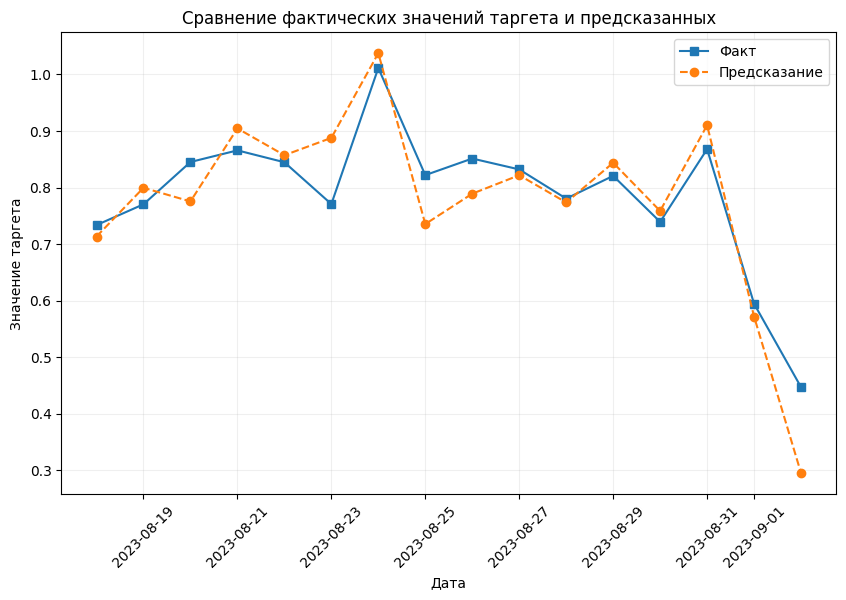

In [205]:
def check_model_prediction(test_data, y_pred, y_test):
    fig, ax = plt.subplots(figsize=(10,6))
    ax.plot(test_data.index, y_test, label='Факт',marker='s')
    ax.plot(test_data.index, y_pred, label='Предсказание', marker='o', linestyle='--')
    plt.title('Сравнение фактических значений таргета и предсказанных')
    plt.xlabel('Дата')
    plt.ylabel('Значение таргета')
    plt.grid(alpha=0.2)
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()


check_model_prediction(test_data=X_test, y_pred=y_pred, y_test=y_test)

In [206]:
X_train.shape

(61, 12)

In [207]:
pipe['preprocessor'].get_feature_names_out()

array(['num__Feature №4', 'num__Feature №5', 'num__Feature №7',
       'num__Feature №8', 'num__Feature №9', 'num__Feature №10',
       'num__Feature №11', 'num__Feature №12', 'num__Feature №13',
       'num__Feature №14', 'num__Feature №15', 'cat__Feature №2_2',
       'cat__Feature №2_3', 'cat__Feature №2_4', 'cat__Feature №2_5'],
      dtype=object)

In [208]:
pipe['model'].coef_ 

array([-0.04281216, -0.02004958, -0.0012757 ,  0.01234794, -0.0006134 ,
       -0.00058085,  0.06163487, -0.00248578,  0.02019876,  0.0054345 ,
       -0.00069051,  0.02839247,  0.0040365 , -0.01144866, -0.00100791])

In [209]:
def show_importance_feature_model(model, type_model):
    if type_model == 'linear':
        coefs = model['model'].coef_ 
    elif type_model == 'tree':
        coefs = model['model'].feature_importances_
    feature = model['preprocessor'].get_feature_names_out()   
    
    if type_model == 'feature_selection':
        mask = model['feature_selection'].get_support()
        feature =  model['preprocessor'].get_feature_names_out()[mask]
        coefs = model['model'].coef_ 
        
    result = pd.DataFrame({
    'feature': feature, 
    'coefficient': coefs
    })

    plt.figure(figsize=(10,6))
    sns.barplot(data=result, x='coefficient', y='feature')
    plt.title('Распределение весов признаков в моделе')
    plt.xlabel('Веса')
    plt.ylabel('Признаки')
    plt.show()


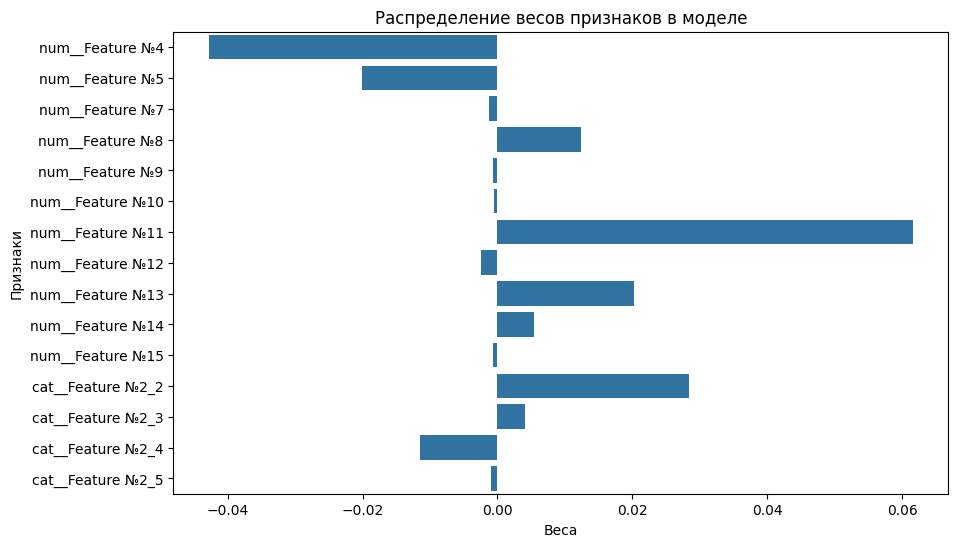

In [210]:
show_importance_feature_model(model=pipe, type_model='linear')

В основном большиство признаков вносят вклад в предсказательную сопособность модели. Есть и явные фавориты один из которых - категориальная фича

# Улучшаем предикт за счет усложнения модели

Обучим случайный лес

In [211]:
from sklearn.ensemble import RandomForestRegressor

pipe_random = Pipeline([('preprocessor', preprocessor),
                        ('model', RandomForestRegressor())])


pipe_random.fit(X_train, y_train)
y_pred = pipe_random.predict(X_test)
y_pred_train = pipe.predict(X_train)

In [212]:
pipe_random['model']

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [213]:
show_all_regressor_metrics(y_pred=y_pred, y_test=y_test, title='Test')
show_all_regressor_metrics(y_pred=y_pred_train, y_test=y_train, title='Train')

=============================Test========================================
R2 - 0.6926197144556924
MSE - 0.004548721960369388
RMSE - 0.06744421369079329
=============================Train========================================
R2 - 0.8751354867916773
MSE - 0.0016418436287147665
RMSE - 0.04051966965209325


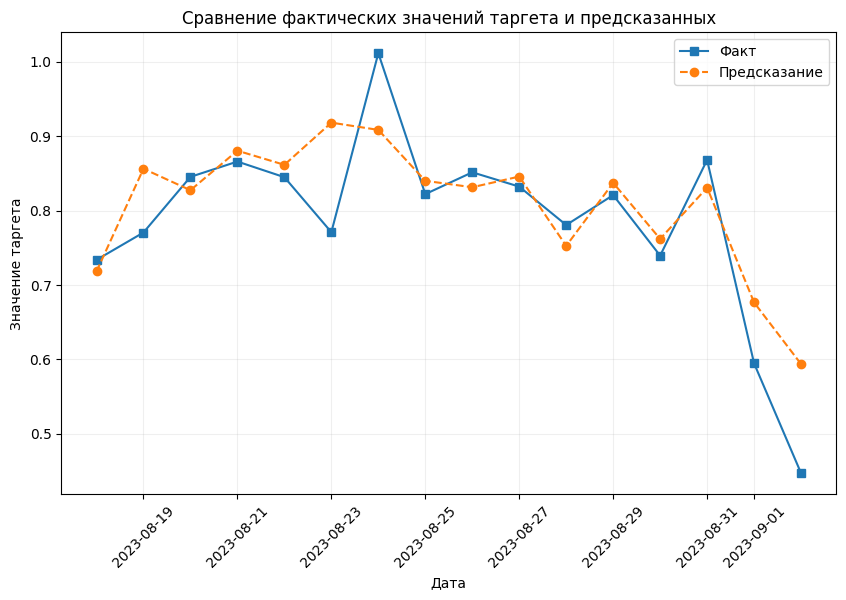

In [214]:
check_model_prediction(test_data=X_test, y_test=y_test, y_pred=y_pred)

In [215]:
pipe_random['model'].feature_importances_

array([3.68267513e-02, 1.17286379e-01, 4.50592552e-02, 2.76836224e-02,
       1.80472496e-02, 1.92392881e-02, 5.65578045e-01, 8.89757024e-03,
       9.98802640e-02, 1.55291900e-02, 2.42235873e-02, 2.02646884e-02,
       6.60580373e-04, 7.26843471e-04, 9.66849091e-05])

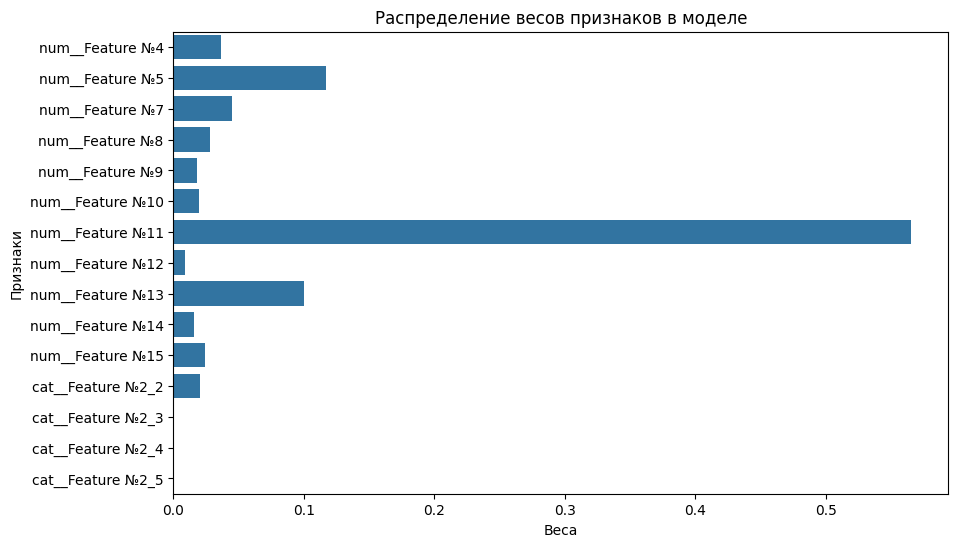

In [216]:
show_importance_feature_model(model=pipe_random, type_model='tree')

Случайный лес напротив категориальые признаки в весах сильно занизил, но как и линейная модель отдал ообое предпочтение признаку №11

Обучим градиентый бустинг

In [217]:
from sklearn.ensemble import GradientBoostingRegressor

pipe_grad_boost = Pipeline([('preprocessor', preprocessor),
                            ('model', GradientBoostingRegressor())])

pipe_grad_boost.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [218]:
y_pred = pipe_grad_boost.predict(X_test)
y_pred_train = pipe_grad_boost.predict(X_train)

In [219]:
show_all_regressor_metrics(y_pred=y_pred, y_test=y_test, title='Test')
show_all_regressor_metrics(y_pred=y_pred_train, y_test=y_train, title='Train')

=============================Test========================================
R2 - 0.6180695953289725
MSE - 0.005651940936886941
RMSE - 0.07517939170335805
=============================Train========================================
R2 - 0.9997707043064522
MSE - 3.015009339884179e-06
RMSE - 0.0017363782248934645


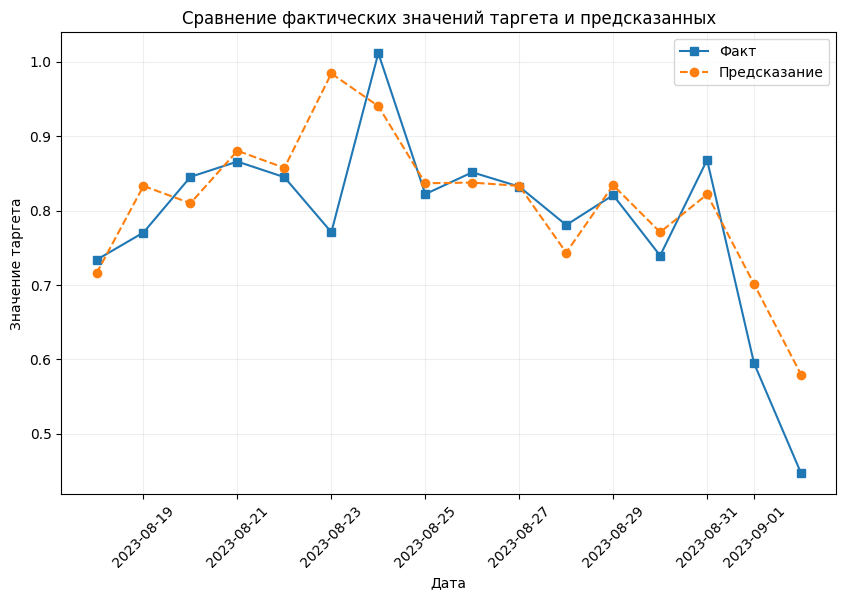

In [220]:
check_model_prediction(test_data=X_test, y_test=y_test, y_pred=y_pred)

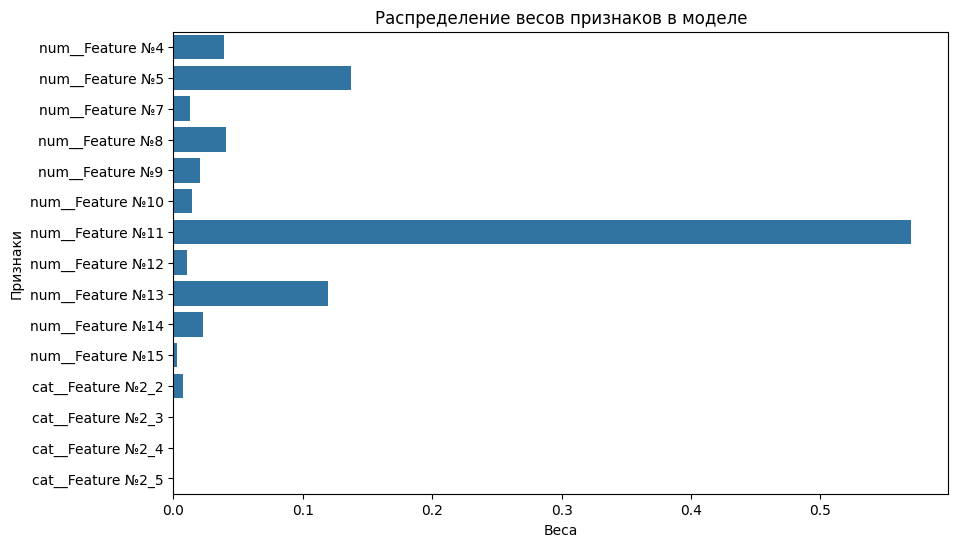

In [221]:
show_importance_feature_model(model=pipe_grad_boost, type_model='tree')

Грандиентный бустинг еще больше снизил, а где-то даже занулил веса категориального признака. Признак № 11 вне конкуренции на во всех трех моделях

## Попробуем обучить линейную модель показавшую лучшее качество на тесте с отбором признаков

In [222]:
from sklearn.feature_selection import SelectFromModel

In [223]:
pipelinear_model_with_feature_selection = Pipeline([('preprocessor', preprocessor),
                                                  ('feature_selection', SelectFromModel(RandomForestRegressor())),
                                                  ('model',Ridge())])

In [224]:
pipelinear_model_with_feature_selection.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [225]:
y_pred = pipelinear_model_with_feature_selection.predict(X_test)
y_pred_train = pipelinear_model_with_feature_selection.predict(X_train)

In [226]:
show_all_regressor_metrics(y_pred=y_pred, y_test=y_test, title='Test')
show_all_regressor_metrics(y_pred=y_pred_train, y_test=y_train, title='Train')

=============================Test========================================
R2 - 0.614063034667294
MSE - 0.005711231435739388
RMSE - 0.07557268974794656
=============================Train========================================
R2 - 0.6832599845407501
MSE - 0.004164814829920178
RMSE - 0.06453537657688362


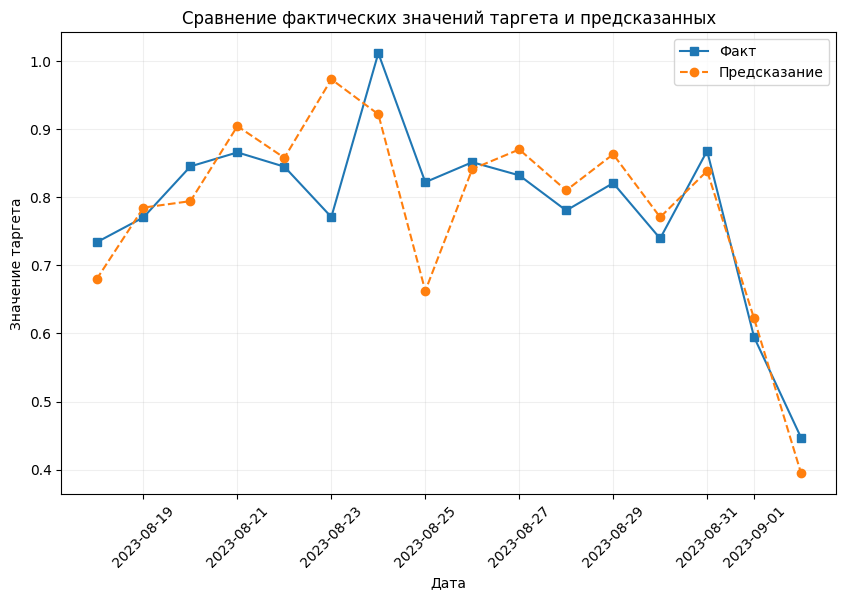

In [227]:
check_model_prediction(test_data=X_test, y_test=y_test, y_pred=y_pred)

Уменьшили переобучение модели за счет учеличения BIAS из-за чего качество на тесте упало на 5 пунктов

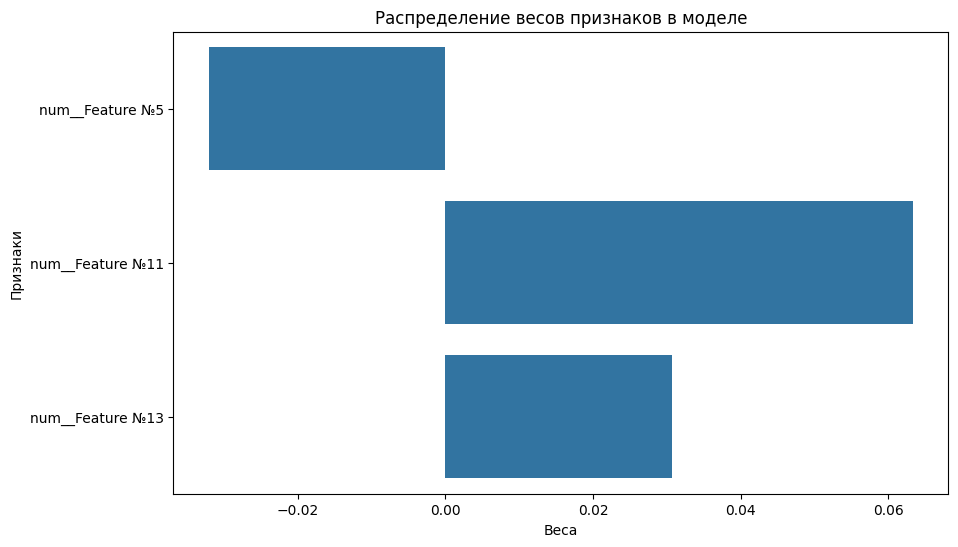

In [228]:
show_importance_feature_model(model=pipelinear_model_with_feature_selection, type_model='feature_selection')

Оценим устойчивость предсказаний нашей модели

In [233]:
print(f'Размер датасета - {X.shape[0]}')


Размер датасета - 77


In [240]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=14,  # 30 дней для теста        
)



In [241]:
from sklearn.metrics import mean_absolute_error

Обучение модели с TimeSeriesSplit:
Fold 1:
  MSE: 0.0136, MAE: 0.0891, RMSE: 0.1167, R2: 0.2223
  Train size: 7, Test size: 14


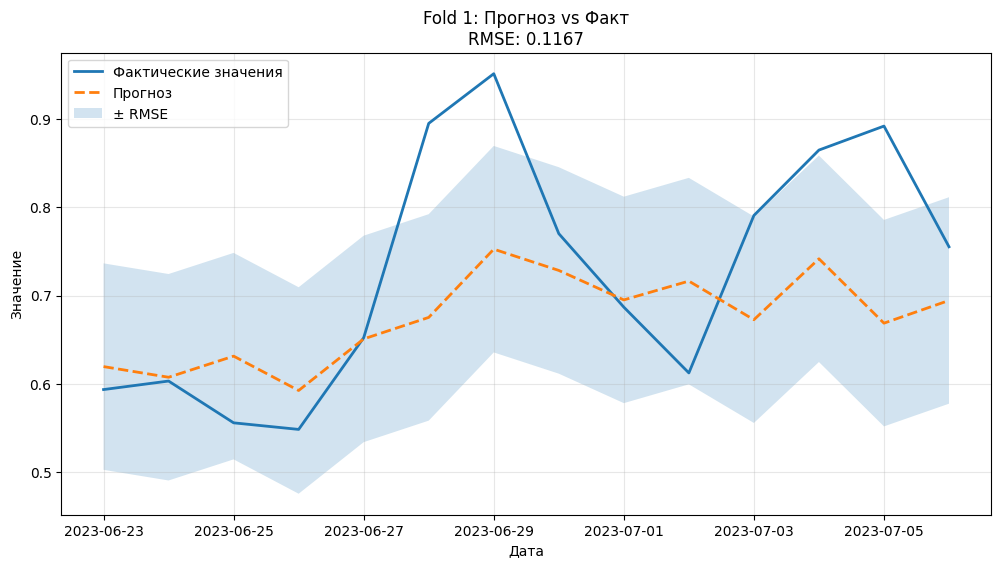

Fold 2:
  MSE: 0.0067, MAE: 0.0671, RMSE: 0.0821, R2: 0.4210
  Train size: 21, Test size: 14


/Users/poltava/Desktop/ML_practice/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


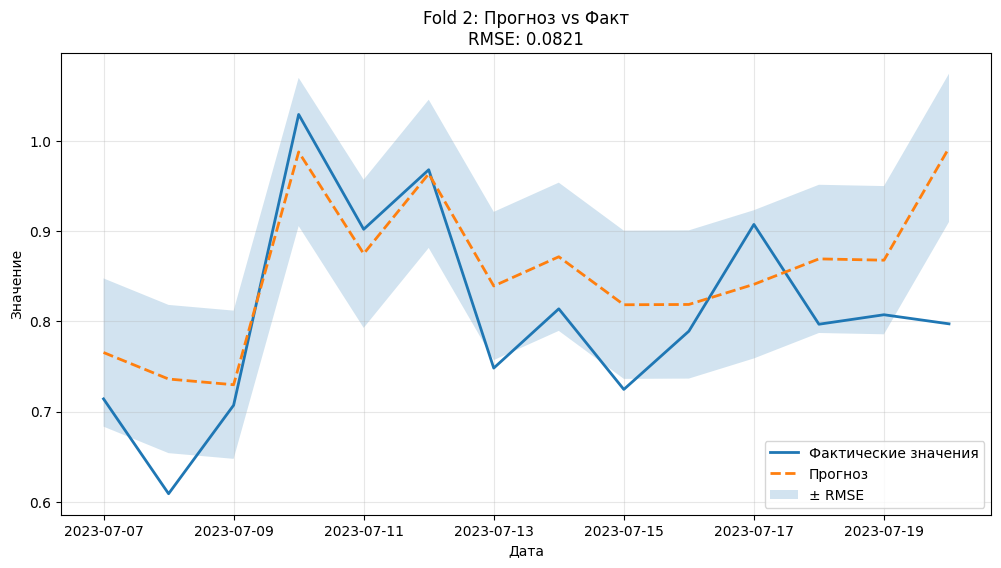

Fold 3:
  MSE: 0.0010, MAE: 0.0250, RMSE: 0.0317, R2: 0.7241
  Train size: 35, Test size: 14


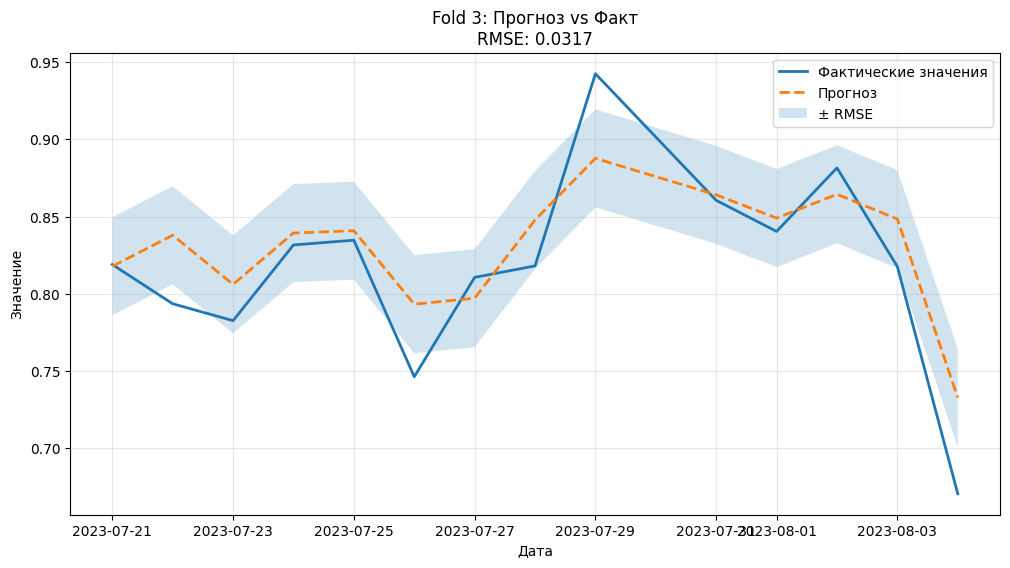

Fold 4:
  MSE: 0.0177, MAE: 0.0653, RMSE: 0.1330, R2: -0.3116
  Train size: 49, Test size: 14


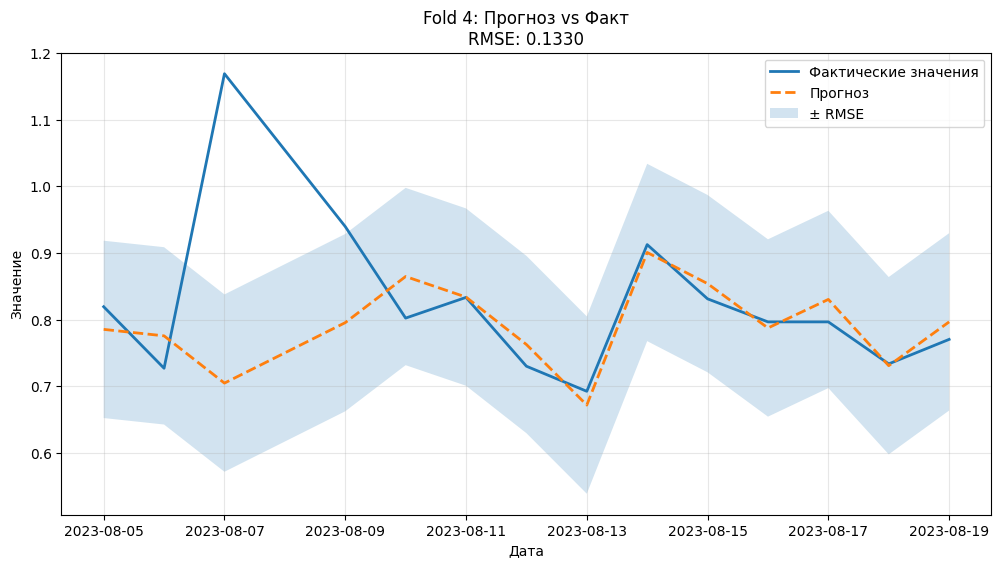

Fold 5:
  MSE: 0.0061, MAE: 0.0572, RMSE: 0.0781, R2: 0.6338
  Train size: 63, Test size: 14


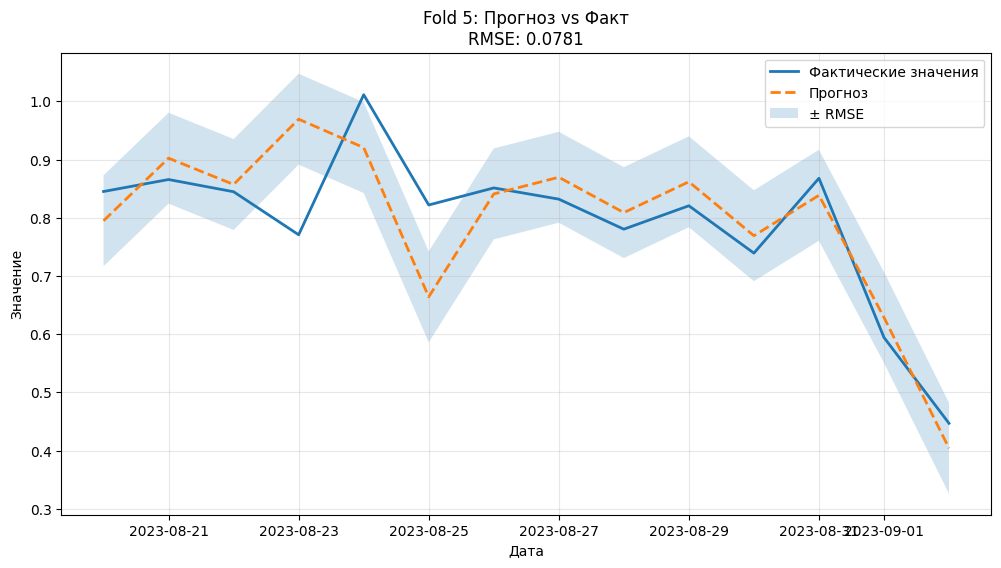


Итоговые метрики:
Среднее MSE:  0.0090 ± 0.0059
Среднее MAE:  0.0607 ± 0.0208
Среднее RMSE: 0.0883 ± 0.0351
Среднее R2: 0.3379 ± 0.0351


In [247]:
# Метрики для каждого фолда
metrics = {
    'mse': [],
    'mae': [],
    'rmse': [],
    'r2': [],
    'train_size': [],
    'test_size': []
}

# Обучение и оценка по фолдам
print("Обучение модели с TimeSeriesSplit:")
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Обучение модели
    pipelinear_model_with_feature_selection.fit(X_train, y_train)
    
    # Предсказание
    y_pred = pipelinear_model_with_feature_selection.predict(X_test)
    
    # Вычисление метрик
    r2 = r2_score(y_true=y_test, y_pred=y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    
    metrics['mse'].append(mse)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)
    metrics['train_size'].append(len(train_index))
    metrics['test_size'].append(len(test_index))
    
    print(f"Fold {fold + 1}:")
    print(f"  MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
    print(f"  Train size: {len(train_index)}, Test size: {len(test_index)}")
    
    # Визуализация прогноза для каждого фолда
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test.values, label='Фактические значения', linewidth=2)
    plt.plot(y_test.index, y_pred, label='Прогноз', linewidth=2, linestyle='--')
    plt.fill_between(y_test.index, y_pred - rmse, y_pred + rmse, 
                    alpha=0.2, label='± RMSE')
    plt.title(f'Fold {fold + 1}: Прогноз vs Факт\nRMSE: {rmse:.4f}')
    plt.xlabel('Дата')
    plt.ylabel('Значение')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Средние метрики
print("\nИтоговые метрики:")
print(f"Среднее MSE:  {np.mean(metrics['mse']):.4f} ± {np.std(metrics['mse']):.4f}")
print(f"Среднее MAE:  {np.mean(metrics['mae']):.4f} ± {np.std(metrics['mae']):.4f}")
print(f"Среднее RMSE: {np.mean(metrics['rmse']):.4f} ± {np.std(metrics['rmse']):.4f}")
print(f"Среднее R2: {np.mean(metrics['r2']):.4f} ± {np.std(metrics['rmse']):.4f}")

## В итоге видим, что модель неплохо улавливает тренды, большая часть предикта не выходит за рамки STD, но есть "пики" в фолдах №3 и №5 которые модель плохо предикти из-за чего на тотале качество модели сильно проседает. 